# Week 1 Project: Medical Insurance Cost Analysis

This notebook uses the **Medical Cost Personal Dataset** from Kaggle.

Dataset link: https://www.kaggle.com/datasets/mirichoi0218/insurance

For the machine learning part, I use Linear Regression to predict medical insurance charges.


## 1. Import the Dataset


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")


## 2. Inspect the Data


In [33]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [35]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Check Missing Values and Duplicates


In [36]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows:
1


In [37]:
df = df.drop_duplicates()

## 3. Basic Filtering

Here I filter the dataset to look at people who are older than 50.


In [38]:
older_people = df[df["age"] > 50]

older_people.head()


,age,sex,bmi,children,smoker,region,charges
9,60,female,25.84,0,no,northwest,28923.13692
11,62,female,26.29,0,yes,southeast,27808.72510
13,56,female,39.82,0,no,southeast,11090.71780
16,52,female,30.78,1,no,northeast,10797.33620
18,56,male,40.30,0,no,southwest,10602.38500


I can also filter the data to look only at smokers, since smoking may be related to higher medical costs.


In [39]:
smokers = df[df["smoker"] == "yes"]

smokers.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


## 4. Grouping and Summary Statistics

I group the data by smoking status and compare the average insurance charges for smokers and non-smokers.


In [40]:
smoker_summary = df.groupby("smoker")["charges"].agg(["mean", "count"])

smoker_summary


,mean,count
smoker,,
no,8440.660307,1063
yes,32050.231832,274


I also group the data by region and calculate the average insurance charge in each region.


In [41]:
region_summary = df.groupby("region")["charges"].mean()

region_summary


region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

### This part aim to try using Polars as well and compare the performance

In [42]:
import polars as pl
import timeit

# Pandas version
def pandas_groupby():
    return df.groupby("smoker")["charges"].mean()

# Polars version
pl_df = pl.read_csv("insurance.csv")

def polars_groupby():
    return pl_df.group_by("smoker").agg(pl.col("charges").mean().alias("average_charges"))

pandas_time = timeit.timeit(pandas_groupby, number=1000)
polars_time = timeit.timeit(polars_groupby, number=1000)

print("Pandas time:", pandas_time)
print("Polars time:", polars_time)

Pandas time: 0.1443096660077572
Polars time: 0.4114560000016354


I compared Pandas and Polars by running the same grouping operation 1000 times.

In this small dataset Pandas is faster than Polars. However, Polars is often faster on larger datasets because it is designed for efficient column-based data processing.

## 5. Visualization

The scatter plot below compares BMI with medical insurance charges.

This helps show whether there is a visible relationship between BMI and insurance cost.


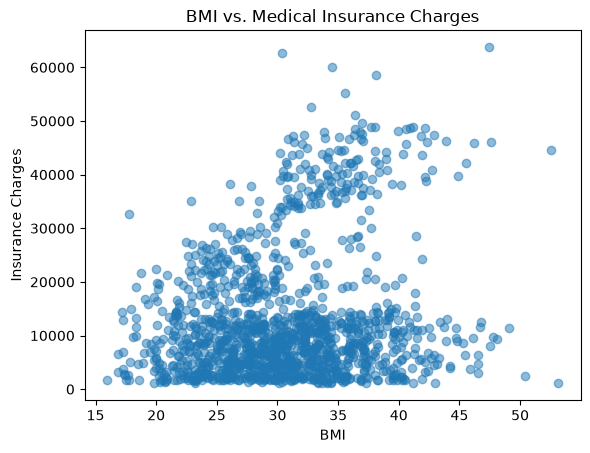

In [43]:
plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs. Medical Insurance Charges")

plt.show()


## 6. Explore a Machine Learning Algorithm

For this project, I chose Linear Regression.

The output variable is `charges`, which is a continuous numerical variable.  
For a simple first model, I use:

- `age`
- `bmi`
- `children`

as the input features.

The goal is to see whether these variables can help predict medical insurance charges. Because the first result is limited, I also build separate Linear Regression models for smokers and non-smokers.


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["age", "bmi", "children"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Train the Linear Regression Model


In [45]:
model = LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[224. ,281.46,690.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5095
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


### Make Predictions


In [46]:
predictions = model.predict(X_test)

print("First 5 predictions:")
print(predictions[:5])


First 5 predictions:
[12217.85512176 11369.7965343  18642.50184425 13600.94185777
 14035.87585693]


### Basic Model Evaluation

I use Mean Squared Error (MSE) and R-squared to get an initial idea of how well the model performs.


In [47]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 158493243.25914004
R-squared: 0.13748020188497823


### Linear Regression by Smoking Status

Because smoking status has a strong relationship with insurance charges, I also fit separate Linear Regression models for smokers and non-smokers.

Each model still uses `age`, `bmi`, and `children` as input features, but the data is split by the `smoker` category first.

In [48]:
# Model for non-smokers
non_smokers = df[df["smoker"] == "no"]

X_no = non_smokers[["age", "bmi", "children"]]
y_no = non_smokers["charges"]

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no,
    y_no,
    test_size=0.2,
    random_state=42
)

model_no = LinearRegression()
model_no.fit(X_train_no, y_train_no)

predictions_no = model_no.predict(X_test_no)

mse_no = mean_squared_error(y_test_no, predictions_no)
r2_no = r2_score(y_test_no, predictions_no)

print("Non-smokers MSE:", mse_no)
print("Non-smokers R-squared:", r2_no)

Non-smokers MSE: 22457821.8583968
Non-smokers R-squared: 0.39181959666891797


In [49]:
# Model for smokers
smokers = df[df["smoker"] == "yes"]

X_yes = smokers[["age", "bmi", "children"]]
y_yes = smokers["charges"]

X_train_yes, X_test_yes, y_train_yes, y_test_yes = train_test_split(
    X_yes,
    y_yes,
    test_size=0.2,
    random_state=42
)

model_yes = LinearRegression()
model_yes.fit(X_train_yes, y_train_yes)

predictions_yes = model_yes.predict(X_test_yes)

mse_yes = mean_squared_error(y_test_yes, predictions_yes)
r2_yes = r2_score(y_test_yes, predictions_yes)

print("Smokers MSE:", mse_yes)
print("Smokers R-squared:", r2_yes)

Smokers MSE: 44740831.330543526
Smokers R-squared: 0.7018194792702654


The grouped models show whether separating smokers and non-smokers improves the fit compared with using one simple model for everyone.

## 7. Initial Findings

This first analysis gives several useful observations:

- The dataset contains demographic and health-related variables that may help explain insurance charges.
- Filtering allows us to focus on groups such as older adults and smokers.
- Grouping by smoking status makes it easy to compare average insurance costs between smokers and non-smokers.
- The BMI scatter plot helps visualize the relationship between BMI and insurance charges.
- Linear Regression provides a simple baseline model for predicting `charges` from numerical features.
- Fitting separate Linear Regression models by `smoker` category can give a better view of the different cost patterns for smokers and non-smokers.
